
# 📘 Module 20: AdaBoost (Adaptive Boosting) – Practice Notebook

This is a **full practice notebook with detailed guidance and TODO blocks**.


## 0. Notebook Setup

We start by importing all required libraries.  


In [29]:
# TODO: Import all required libraries (Done for you)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression


## 1. Understanding the Dataset

You can begin with a **synthetic binary classification dataset**. or with any exisiting dataset.

Focus questions:
- Are the classes easily separable?
- Will a weak learner struggle?


In [2]:
# TODO: Generate a binary classification dataset
# Hint:
# - n_samples around 500
# - n_features = 2
# - class_sep > 1
X,y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    class_sep=1.2,
    random_state=42
)

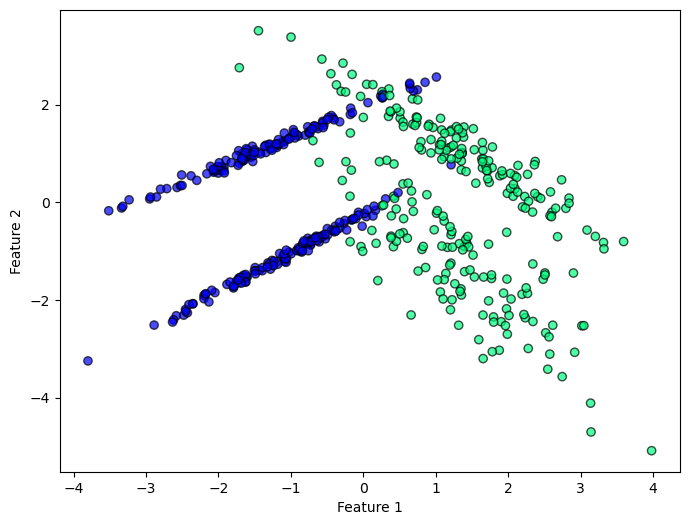

In [3]:
# TODO: Visualize the dataset using a scatter plot
# Color points by class label

# plt.scatter(...)
# plt.show()
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',edgecolors='k',alpha=0.7)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## 2. Train–Test Split

Before any model training, we split the data.

Why?
- To evaluate generalization
- To avoid lying to ourselves

Standard split:
- 70% training
- 30% testing


In [4]:
# TODO: Split the dataset into training and testing sets
# Use test_size=0.3 and random_state=42
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
print(f"training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

training set size: 350
Testing set size: 150



## 3. Baseline Weak Learner (Decision Stump)

Before AdaBoost, we test **one weak learner alone**.

We intentionally restrict the model:
- max_depth = 1
- This is called a **decision stump**

Expectation:
- Accuracy will not be impressive
- That is the point


In [6]:
# TODO: Create a DecisionTreeClassifier with max_depth=1
weak_learner = DecisionTreeClassifier(max_depth=1,random_state=42)
# SVM, Logistic Regression
# This is our weak learner

In [9]:
# TODO: Train the weak learner
weak_learner.fit(X_train,y_train)
# TODO: Predict on test data
y_pred_weak = weak_learner.predict(X_test)
# TODO: Calculate and print accuracy
weak_accuracy = accuracy_score(y_test,y_pred_weak)
print(f"Weak learner accuracy: {weak_accuracy:.4f}")

Weak learner accuracy: 0.8867



## 4. AdaBoost Classifier – Core Practice

Now we combine **many weak learners** using AdaBoost.

Key idea:
- Each learner focuses more on previous mistakes
- Misclassified samples get more attention
- Correctly classified samples slowly matter less


In [12]:
# TODO: Initialize AdaBoostClassifier
# Use:
# - base_estimator = decision stump
# - n_estimators = 50
# - learning_rate = 1.0
ada_model = AdaBoostClassifier(
    estimator=weak_learner,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

In [14]:
# TODO: Train AdaBoost on training data
ada_model.fit(X_train,y_train)
# TODO: Predict on test data
y_pred_ada = ada_model.predict(X_test)
# TODO: Evaluate accuracy
ada_accuracy = accuracy_score(y_test,y_pred_ada)
# TODO: Print classification report
print(f"AdaBoost accuracy: {ada_accuracy:.4f}")
print("\nClassification report:\n",classification_report(y_test,y_pred_ada))

AdaBoost accuracy: 0.9133

Classification report:
               precision    recall  f1-score   support

           0       0.97      0.86      0.91        78
           1       0.86      0.97      0.92        72

    accuracy                           0.91       150
   macro avg       0.92      0.92      0.91       150
weighted avg       0.92      0.91      0.91       150




## 5. Weak Learner vs AdaBoost Comparison

Now we compare:
- One weak learner
- Many weak learners working together

Expectation:
- AdaBoost should outperform a single stump
- If not, something is wrong


In [15]:
# TODO: Create a comparison table
# Columns:
# - Model
# - Accuracy
com_df = pd.DataFrame({
    "Model":["Single decision Stump","AdaBoost (50 stumps)"],
    "Accuracy":[weak_accuracy,ada_accuracy]
})
print(com_df)

                   Model  Accuracy
0  Single decision Stump  0.886667
1   AdaBoost (50 stumps)  0.913333



## 6. Effect of Number of Estimators

AdaBoost performance depends heavily on:
- Number of estimators

More is not always better.

Your job:
- Experiment
- Observe
- Plot


In [18]:
# TODO: Try different n_estimators values
# Example: [5, 10, 20, 50, 100]
# Store accuracy for each value

n_estimators_list = [1,5,10,20,50,100,200]
accuracies = []

for n in n_estimators_list:
    model = AdaBoostClassifier(estimator=weak_learner,n_estimators=n,random_state=42)
    model.fit(X_train,y_train)
    acc = accuracy_score(y_test,model.predict(X_test))
    accuracies.append(acc)

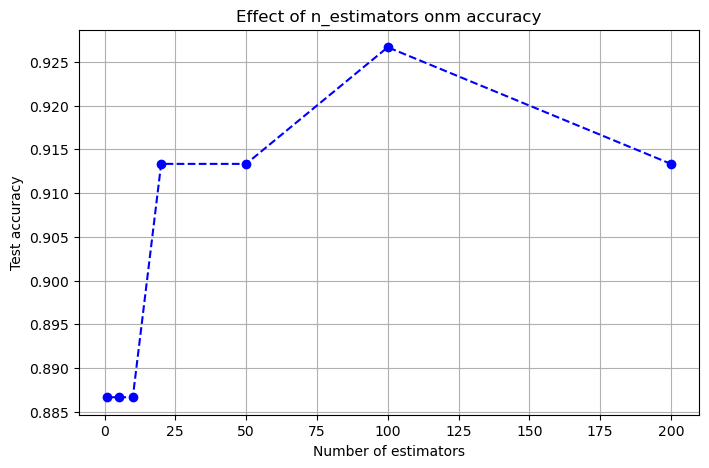

In [23]:
# TODO: Plot n_estimators vs accuracy
# Label axes clearly
plt.figure(figsize=(8,5))
plt.plot(n_estimators_list,accuracies,marker='o',linestyle='--',color='b')
plt.title("Effect of n_estimators onm accuracy")
plt.xlabel("Number of estimators")
plt.ylabel("Test accuracy")
plt.grid(True)
plt.show()


## 7. Effect of Learning Rate

Learning rate controls **how aggressively** AdaBoost updates sample weights.

Intuition:
- High learning rate → fast but risky
- Low learning rate → slow but stable

You will verify this experimentally.


In [25]:
# TODO: Experiment with different learning_rate values
# Example: [0.01, 0.1, 0.5, 1.0]
learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0]
lr_accuracies = []

for lr in learning_rates:
    model = AdaBoostClassifier(estimator=weak_learner,n_estimators=50,learning_rate=lr,random_state=42)
    model.fit(X_train,y_train)
    acc = accuracy_score(y_test,model.predict(X_test))
    lr_accuracies.append(acc)

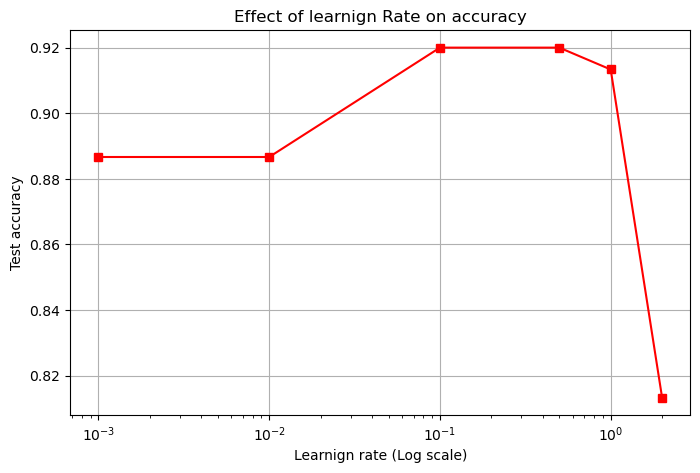

In [26]:
# TODO: Plot learning_rate vs accuracy
plt.figure(figsize=(8,5))
plt.plot(learning_rates,lr_accuracies,marker='s',color='r')
plt.xscale('log')
plt.title("Effect of learnign Rate on accuracy")
plt.xlabel("Learnign rate (Log scale)")
plt.ylabel("Test accuracy")
plt.grid(True)
plt.show()


## 8. Feature Importance in AdaBoost

AdaBoost can tell us:
- Which features were more influential

This depends on:
- How often a feature is used in splits
- How strong the corresponding learners were


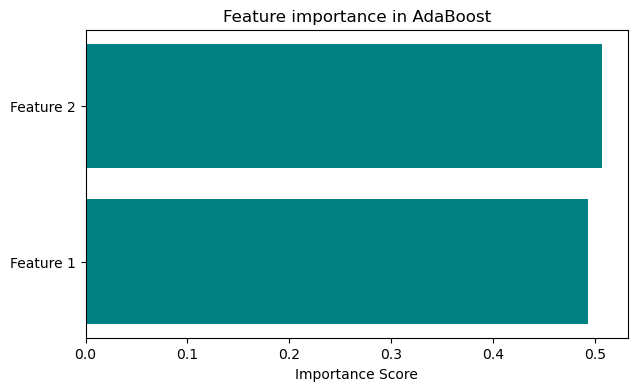

In [28]:
# TODO: Extract feature importance from AdaBoost
# TODO: Plot feature importance
importances = ada_model.feature_importances_
feature_names = [f"Feature {i+1}" for i in range(X.shape[1])]

plt.figure(figsize=(7,4))
plt.barh(feature_names,importances,color='teal')
plt.title("Feature importance in AdaBoost")
plt.xlabel("Importance Score")
plt.show()


## 9. Reflection (Mandatory)

Answer in your own words.

1. Why is AdaBoost called *adaptive*?
2. What happens to misclassified samples after each iteration?
3. Why do we prefer weak learners instead of strong ones?
4. When should AdaBoost not be used?



## 10. Bonus Challenge (Optional)

Replace the decision stump with **Logistic Regression** as the base estimator.

Questions:
- Does AdaBoost still work?
- Should you do this in practice?
- Why or why not?


In [30]:
# TODO: Replace DecisionTreeClassifier with LogisticRegression or SVM
# Train AdaBoost again
# Compare performance
lr_base = LogisticRegression()
ada_lr = AdaBoostClassifier(estimator=lr_base,n_estimators=50,random_state=42)

ada_lr.fit(X_train,y_train)
acc = accuracy_score(y_test,ada_lr.predict(X_test))
print(f"Adaboost with logistic regresssion accuracy: {acc:.4f}")

Adaboost with logistic regresssion accuracy: 0.9067
